In [1]:
pip install opencv-python matplotlib pywavelets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 22.8 MB/s eta 0:00:00


Saving wce.jpeg to wce.jpeg


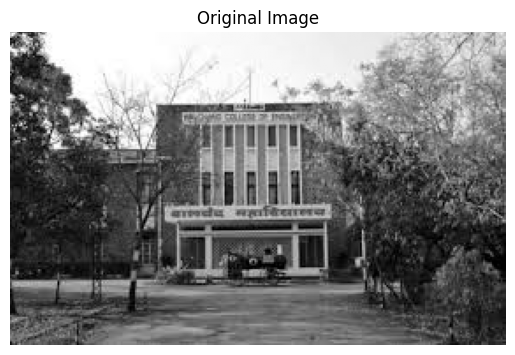

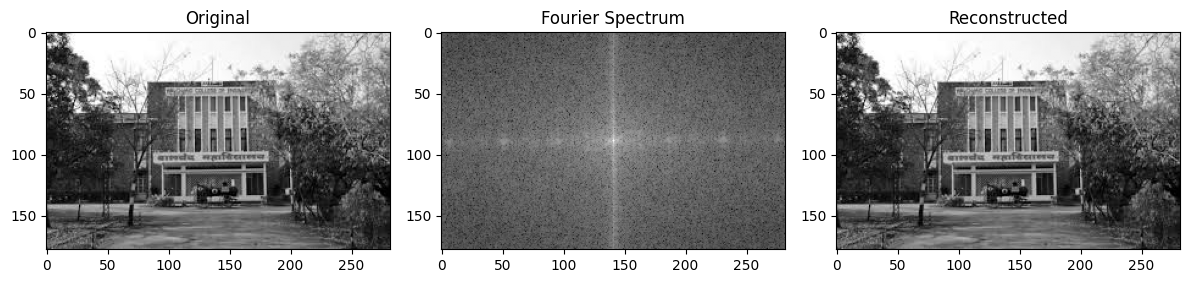

In [4]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load as grayscale for transform operations
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Apply Fourier Transform
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

# Inverse Fourier Transform
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Fourier Spectrum')
plt.subplot(1, 3, 3), plt.imshow(img_back, cmap='gray'), plt.title('Reconstructed')
plt.tight_layout()
plt.show()


Saving wce.jpeg to wce (1).jpeg


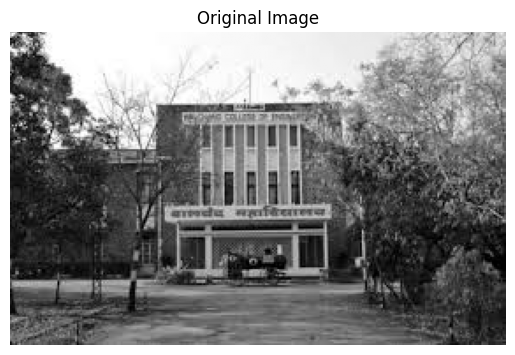

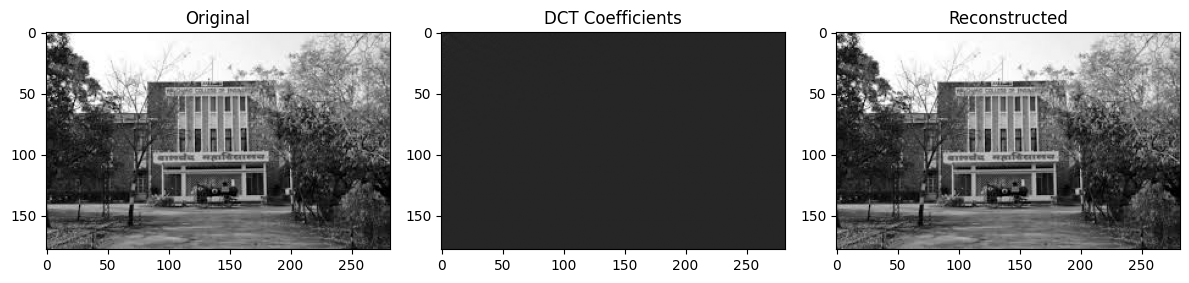

In [5]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load as grayscale for transform operations
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Convert image to float32
img_float = np.float32(img) / 255.0

# Apply DCT
dct = cv2.dct(img_float)

# Inverse DCT
img_dct_back = cv2.idct(dct)

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(dct, cmap='gray'), plt.title('DCT Coefficients')
plt.subplot(1, 3, 3), plt.imshow(img_dct_back, cmap='gray'), plt.title('Reconstructed')
plt.tight_layout()
plt.show()


Saving wce.jpeg to wce (2).jpeg


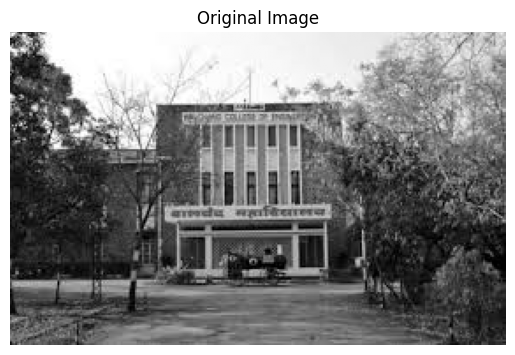

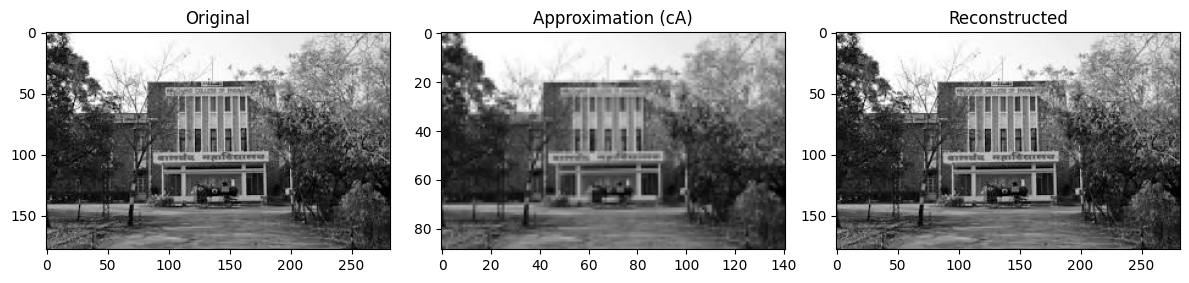

In [6]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load as grayscale for transform operations
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

import pywt

# Apply 2D Wavelet Transform
coeffs2 = pywt.dwt2(img, 'haar')
cA, (cH, cV, cD) = coeffs2

# Inverse Wavelet Transform
img_wavelet_back = pywt.idwt2(coeffs2, 'haar')

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(cA, cmap='gray'), plt.title('Approximation (cA)')
plt.subplot(1, 3, 3), plt.imshow(img_wavelet_back, cmap='gray'), plt.title('Reconstructed')
plt.tight_layout()
plt.show()



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image_path = 'path/to/image.jpg'  # Replace with actual path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found or invalid path.")

# --- Fourier Transform (DFT) ---
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shifted = np.fft.fftshift(dft)  # Shift zero frequency component to center

# Inverse Fourier Transform to get the image back
dft_ishifted = np.fft.ifftshift(dft_shifted)
img_back_dft = cv2.idft(dft_ishifted)
img_back_dft = cv2.magnitude(img_back_dft[:, :, 0], img_back_dft[:, :, 1])

# Show images
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_back_dft, cmap='gray')
plt.title("Reconstructed from Fourier Transform")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image_path = 'path/to/image.jpg'  # Replace with actual path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found or invalid path.")

# --- Discrete Cosine Transform (DCT) ---
img_float32 = np.float32(img) / 255.0  # Normalize image to [0, 1]
dct = cv2.dct(img_float32)  # Apply DCT

# Inverse DCT to get the image back
img_back_dct = cv2.idct(dct) * 255.0  # Multiply by 255 to bring it back to [0, 255]

# Show images
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_back_dct, cmap='gray')
plt.title("Reconstructed from DCT")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image_path = 'path/to/image.jpg'  # Replace with actual path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found or invalid path.")

# --- Wavelet Transform (Haar) ---
coeffs = pywt.dwt2(img, 'haar')  # 2D Haar Wavelet Transform
cA, (cH, cV, cD) = coeffs  # cA: Approximation coefficients, cH: Horizontal, cV: Vertical, cD: Diagonal

# Inverse Wavelet Transform to get the image back
img_back_wavelet = pywt.idwt2(coeffs, 'haar')

# Show images
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_back_wavelet, cmap='gray')
plt.title("Reconstructed from Wavelet Transform")
plt.axis('off')

plt.tight_layout()
plt.show()
